In [1]:
import numpy as np
import cv2
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascade_eye.xml')

In [3]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not read image: {image_path}")
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray,scaleFactor=1.3,minNeighbors=5)
    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color
    return None

In [4]:
import os

path_to_data = "./dataset/"
path_to_cr_data = "./dataset/cropped/"

img_dirs= []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
img_dirs

['./dataset/allu',
 './dataset/mahesh',
 './dataset/mrunal',
 './dataset/prabhas',
 './dataset/rashmika',
 './dataset/samantha']

In [5]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

### Croping out just the face of all the images 

In [7]:
#creating the cropped folder to store all the roi_color images
#still manual cleaning was rewuired to remove the bad images

cropped_image_dirs=[]
idol_file_names_dict = {}
for img_dir in img_dirs:
    count = 1
    idol_name = img_dir.split('/')[-1]
    print(idol_name)

    idol_file_names_dict[idol_name] = []
    
    for entry in os.scandir(img_dir):
        roi_color = get_cropped_image_if_2_eyes(entry.path)
        if roi_color is not None:
            cropped_folder = path_to_cr_data + idol_name
            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)
                print("Generating cropped images in folder: ", cropped_folder)
                
            cropped_file_name = idol_name +str(count) + ".png"
            cropped_file_path = cropped_folder + "/" + cropped_file_name
            cv2.imwrite(cropped_file_path, roi_color)
            idol_file_names_dict[idol_name].append(cropped_file_path)
            count+=1

allu
Generating cropped images in folder:  ./dataset/cropped/allu
mahesh
Generating cropped images in folder:  ./dataset/cropped/mahesh
mrunal
Generating cropped images in folder:  ./dataset/cropped/mrunal
prabhas
Generating cropped images in folder:  ./dataset/cropped/prabhas
rashmika
Generating cropped images in folder:  ./dataset/cropped/rashmika
samantha
Generating cropped images in folder:  ./dataset/cropped/samantha


In [20]:
import random

# Count images in each class
class_counts = {}

for folder in cropped_image_dirs:
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[folder] = len(images)

print(class_counts)

# Minimum number of images among all classes
min_count = min(class_counts.values())

print("Keeping", min_count, "images in each class.")

# Remove extra images
for folder in cropped_image_dirs:
    images = [f for f in os.listdir(folder)
              if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    random.shuffle(images)

    # Delete extra images
    for image in images[min_count:]:
        os.remove(os.path.join(folder, image))

print("Dataset balanced successfully!")

{'./dataset/cropped/allu': 101, './dataset/cropped/mahesh': 129, './dataset/cropped/mrunal': 182, './dataset/cropped/prabhas': 111, './dataset/cropped/rashmika': 173, './dataset/cropped/samantha': 172}
Keeping 101 images in each class.
Dataset balanced successfully!


In [14]:
#creating an file list
idol_file_names_dict={}
for img_dir in cropped_image_dirs:
    idol_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    idol_file_names_dict[idol_name]=file_list
idol_file_names_dict

{'allu': ['./dataset/cropped/allu\\allu10.png',
  './dataset/cropped/allu\\allu100.png',
  './dataset/cropped/allu\\allu101.png',
  './dataset/cropped/allu\\allu102.png',
  './dataset/cropped/allu\\allu103.png',
  './dataset/cropped/allu\\allu104.png',
  './dataset/cropped/allu\\allu105.png',
  './dataset/cropped/allu\\allu107.png',
  './dataset/cropped/allu\\allu108.png',
  './dataset/cropped/allu\\allu11.png',
  './dataset/cropped/allu\\allu110.png',
  './dataset/cropped/allu\\allu111.png',
  './dataset/cropped/allu\\allu112.png',
  './dataset/cropped/allu\\allu113.png',
  './dataset/cropped/allu\\allu114.png',
  './dataset/cropped/allu\\allu116.png',
  './dataset/cropped/allu\\allu117.png',
  './dataset/cropped/allu\\allu118.png',
  './dataset/cropped/allu\\allu119.png',
  './dataset/cropped/allu\\allu12.png',
  './dataset/cropped/allu\\allu122.png',
  './dataset/cropped/allu\\allu123.png',
  './dataset/cropped/allu\\allu124.png',
  './dataset/cropped/allu\\allu127.png',
  './datase

In [16]:
#finding out each record y value
class_dict = {}
count=0
for idol_name in idol_file_names_dict.keys():
    class_dict[idol_name] = count
    count+=1
class_dict

{'allu': 0,
 'mahesh': 1,
 'mrunal': 2,
 'prabhas': 3,
 'rashmika': 4,
 'samantha': 5}

### Wavelet Transformation

In [19]:
#wavelet transformation to extract impoirtant information for the computer 
#to understand the images

import pywt

def w2d(img, mode='haar', level=3):
    imArray = img
    #Datatype conversions
    #convert from clor to gray scale
    imArray= cv2.cvtColor(imArray, cv2.COLOR_RGB2GRAY)
    #convert to float
    imArray=np.float32(imArray)
    imArray/=255;
    #compute coefficients
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #process Coefficients
    coeffs_H=list(coeffs)
    coeffs_H[0]*=0;
    #reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *=255;
    imArray_H= np.uint8(imArray_H)
    return imArray_H
    

In [20]:
#Creating X and y for model prediction
X=[]
y=[]

for idol_name, training_files in idol_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scaled_raw_img = cv2.resize(img, (64,64))
        img_har = w2d(img, 'db4',3)
        scaled_img_har = cv2.resize(img_har, (64,64))
        combined_img = np.vstack((scaled_raw_img.reshape(64*64*3,1), scaled_img_har.reshape(64*64,1)))
        X.append(combined_img)
        y.append(class_dict[idol_name])

In [21]:
X=np.array(X).reshape(len(X), 16384).astype(float)
X.shape

(882, 16384)

In [22]:
#model training first using SVM

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([('scalar', StandardScaler()), ('svc', SVC(kernel = 'rbf', C=10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.7457627118644068

In [24]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      0.62      0.74        26
           1       0.64      0.86      0.73        21
           2       0.72      0.71      0.72        41
           3       0.86      0.83      0.84        23
           4       0.62      0.93      0.74        28
           5       0.86      0.63      0.73        38

    accuracy                           0.75       177
   macro avg       0.77      0.76      0.75       177
weighted avg       0.78      0.75      0.75       177



In [25]:
#Grid Search CV
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [26]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto', probability=True),
        'params':{ 
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver = 'liblinear', multi_class='auto'),
        'params': {
            'logisticregression__C':[1,5,10]
        }
    }
}

In [27]:
scores=[]
best_estimators={}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf = GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
df = pd.DataFrame(scores, columns=['model','best_score', 'best_params'])
df

,model,best_score,best_params
0,svm,0.754610,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.513475,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.734752,{'logisticregression__C': 1}


In [28]:
best_estimators['svm'].score(X_test, y_test)

0.7740112994350282

In [30]:
best_estimators['random_forest'].score(X_test, y_test)

0.5084745762711864

In [31]:
best_estimators['logistic_regression'].score(X_test, y_test)

0.7740112994350282

In [32]:
best_clf = best_estimators['svm']

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, best_clf.predict(X_test))
cm

array([[22,  1,  1,  2,  0,  0],
       [ 0, 18,  0,  0,  3,  0],
       [ 0,  1, 32,  0,  5,  3],
       [ 1,  4,  0, 17,  0,  1],
       [ 0,  1,  1,  0, 24,  2],
       [ 0,  3,  6,  0,  5, 24]], dtype=int64)

Text(95.72222222222221, 0.5, 'Truth')

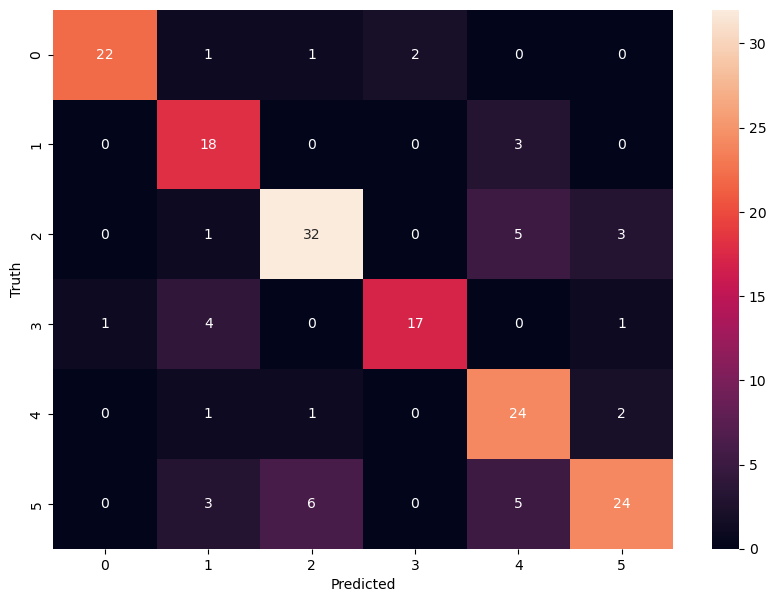

In [33]:
import seaborn as sn

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [47]:
#Saving the best model
!pip install joblib
import joblib

joblib.dump(best_clf, 'saved_model.pkl')


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


['saved_model.pkl']

In [49]:
#dave class dictionary
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))